In [14]:
import pandas as pd
import numpy as np


In [15]:
df=pd.read_csv("Mall_Customers.csv")

In [16]:
print(f" Total customer: {df.shape[0]}")
print(f"columns: {list(df.columns)}")

 Total customer: 200
columns: ['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']


In [17]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [18]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [19]:
duplictaed_count=df.duplicated().sum()
print(f"\nDuplicate row: {duplictaed_count}")


Duplicate row: 0


In [28]:
df.rename(columns={
    "Annual Income (k$)":"Annual income",
    "Spending Score (1-100)":"Spending Score"
          
},inplace=True)
print(df)

     CustomerID  Gender  Age  Annual income  Spending Score
0             1    Male   19             15              39
1             2    Male   21             15              81
2             3  Female   20             16               6
3             4  Female   23             16              77
4             5  Female   31             17              40
..          ...     ...  ...            ...             ...
195         196  Female   35            120              79
196         197  Female   45            126              28
197         198    Male   32            126              74
198         199    Male   32            137              18
199         200    Male   30            137              83

[200 rows x 5 columns]


In [31]:
x=df[["Annual income","Spending Score"]]


In [35]:
print(x.describe())

       Annual income  Spending Score
count     200.000000      200.000000
mean       60.560000       50.200000
std        26.264721       25.823522
min        15.000000        1.000000
25%        41.500000       34.750000
50%        61.500000       50.000000
75%        78.000000       73.000000
max       137.000000       99.000000


In [36]:
from sklearn.preprocessing import StandardScaler


In [37]:
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)

In [39]:
x_scaled_df=pd.DataFrame(x_scaled,columns=x.columns)

In [40]:
from sklearn.cluster import KMeans


In [42]:
inertia_values = []
k_range = range(1, 11)
 
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(x_scaled)
    inertia_values.append(km.inertia_)


In [43]:
for k, inertia in zip(k_range, inertia_values):
    print(f"  K={k} -> Inertia = {inertia:.2f}")

  K=1 -> Inertia = 400.00
  K=2 -> Inertia = 269.69
  K=3 -> Inertia = 157.70
  K=4 -> Inertia = 108.92
  K=5 -> Inertia = 65.57
  K=6 -> Inertia = 55.06
  K=7 -> Inertia = 44.86
  K=8 -> Inertia = 37.23
  K=9 -> Inertia = 32.39
  K=10 -> Inertia = 29.98


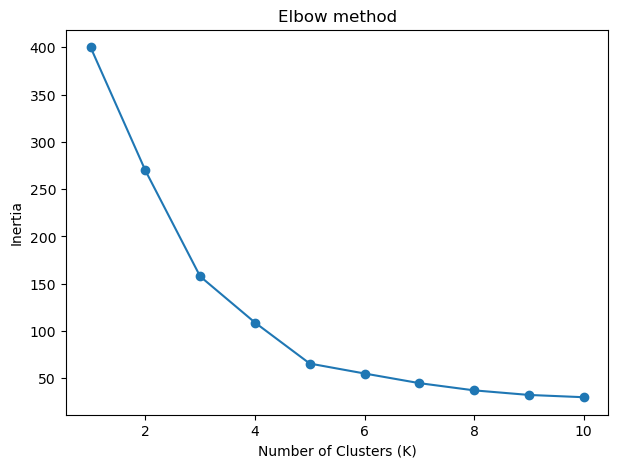

In [45]:
import matplotlib.pyplot as plt
 
plt.figure(figsize=(7, 5))
plt.plot(k_range, inertia_values, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow method")
plt.show()

In [50]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(x_scaled)

In [51]:
print(df["Cluster"].value_counts().sort_index())

Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


In [54]:
cluster_summary = df.groupby("Cluster")[["Annual income", "Spending Score"]].mean()
print(cluster_summary)

         Annual income  Spending Score
Cluster                               
0            55.296296       49.518519
1            86.538462       82.128205
2            25.727273       79.363636
3            88.200000       17.114286
4            26.304348       20.913043


In [56]:
for cluster_id, row in cluster_summary.iterrows():
    income = row["Annual income"]
    spending = row["Spending Score"]
    if income < 40 and spending < 40:
        label = "Careful Spenders."
    elif income < 40 and spending > 60:
        label = "Impulsive."
    elif income > 70 and spending < 40:
        label = "Careful Rich."
    elif income > 70 and spending > 60:
        label = "Target Customers."
    else:
        label = "Average or Standard Customers"
    print(f"  Cluster {cluster_id}: {label}")
 

  Cluster 0: Average or Standard Customers
  Cluster 1: Target Customers.
  Cluster 2: Impulsive.
  Cluster 3: Careful Rich.
  Cluster 4: Careful Spenders.


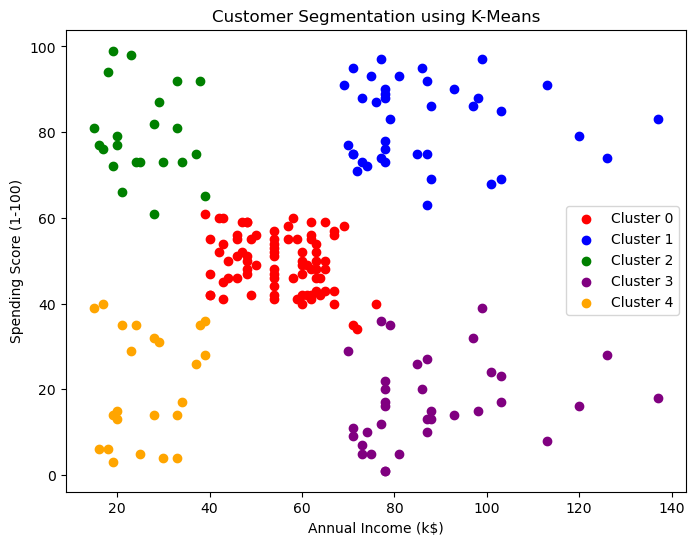

In [60]:
plt.figure(figsize=(8, 6))
colors = ["red", "blue", "green", "purple", "orange"]

for cluster_id in sorted(df["Cluster"].unique()):
    cluster_data = df[df["Cluster"] == cluster_id]
    plt.scatter(
        cluster_data["Annual income"],
        cluster_data["Spending Score"],
        label=f"Cluster {cluster_id}",
        color=colors[cluster_id]
    )

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segmentation using K-Means")
plt.legend()
plt.show()